In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ace_tools_open as tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import ace_tools_open as tools
import plotly
from neuralprophet import NeuralProphet
import torch
from neuralprophet.configure import ConfigSeasonality
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product
import joblib

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.452% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a futu

Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.data.splitting._make_future_dataframe) - Not extending df into future as no periods specified. You can skip this and predict directly instead.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 97.452% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - c:\Users\Wesley\AppData\Local\Programs\Python\Python311\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is depre

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


===== NeuralProphet Performance Metrics (Last 120 Days) =====
MAE  : 187.32   (2.46%)
RMSE : 244.73   (3.22%)


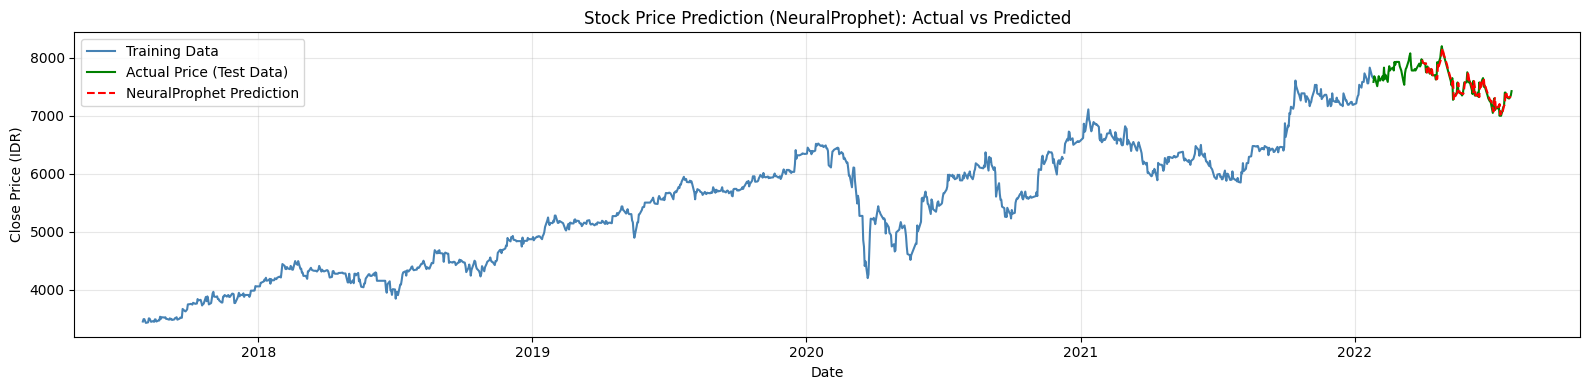

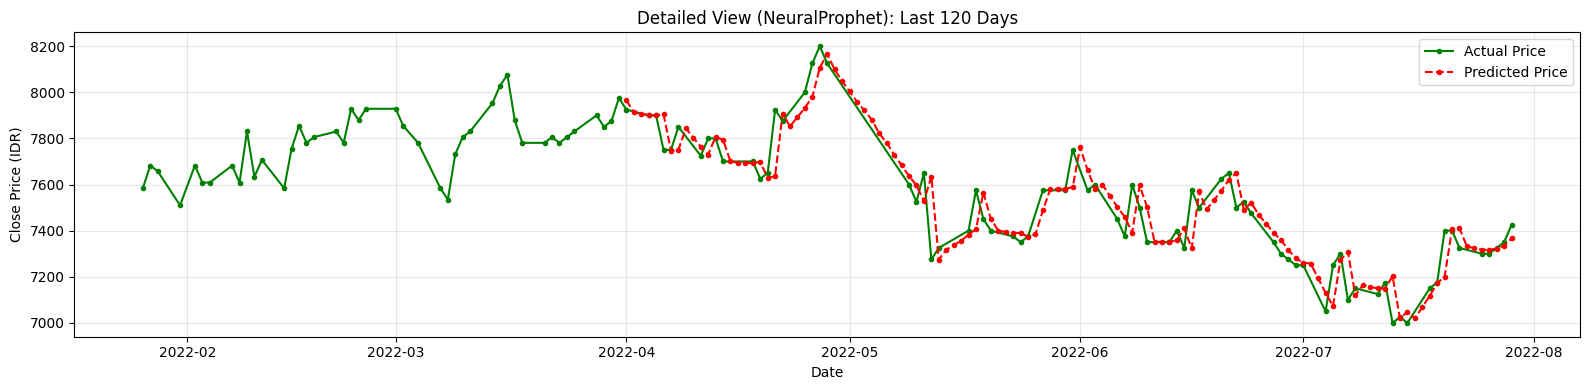

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet

# 1. Load raw data
df_raw = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx")
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw = df_raw.sort_values("Date")

# 2. Rename to NeuralProphet formast: ds = date, y = target
df = df_raw.rename(columns={"Date": "ds", "Close": "y"})[["ds", "y"]]

# 3. Choose how many days you want to "treat as test"
test_size = 120

# 4. Build & fit NeuralProphet (best hyperparameters)
model = NeuralProphet(
    n_lags=1,
    n_forecasts=1,
    learning_rate=0.01,
    seasonality_mode='additive',
    epochs=100,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    quantiles=[0.05, 0.95],
)

model.add_seasonality(name="quarterly", period=91.31, fourier_order=5)

metrics = model.fit(df, freq="D")

# 5. Make predictions for the WHOLE history (no future steps yet)
future = model.make_future_dataframe(
    df,
    periods=0,                    # no extra future, only history
    n_historic_predictions=True   # <-- VERY IMPORTANT
)
forecast = model.predict(future)

# 6. Split into "train" and "test" segments for plotting
train_actual   = df.iloc[:-test_size].copy()
test_actual    = df.iloc[-test_size:].copy()

train_pred     = forecast.iloc[:-test_size].copy()
test_pred      = forecast.iloc[-test_size:].copy()

# 7. FULL VIEW: training + last 120 days (actual vs predicted)
plt.figure(figsize=(16, 4))

plt.plot(train_actual["ds"], train_actual["y"],
         label="Training Data", color="steelblue")

plt.plot(test_actual["ds"], test_actual["y"],
         label="Actual Price (Test Data)", color="green")

plt.plot(test_pred["ds"], test_pred["yhat1"],
         "r--", label="NeuralProphet Prediction")

# Extract actual and predicted arrays
y_true = test_actual["y"].values
y_pred = test_pred["yhat1"].values

# Compute base errors
MAE  = mean_absolute_error(y_true, y_pred)
RMSE = np.sqrt(mean_squared_error(y_true, y_pred))

# Convert to %
mean_price = np.mean(y_true)

MAE_percent  = (MAE  / mean_price) * 100
RMSE_percent = (RMSE / mean_price) * 100

print("===== NeuralProphet Performance Metrics (Last 120 Days) =====")
print(f"MAE  : {MAE:,.2f}   ({MAE_percent:.2f}%)")
print(f"RMSE : {RMSE:,.2f}   ({RMSE_percent:.2f}%)")

plt.title("Stock Price Prediction (NeuralProphet): Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Close Price (IDR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. ZOOMED VIEW: last 120 days only
plt.figure(figsize=(16, 4))

plt.plot(test_actual["ds"], test_actual["y"],
         "g.-", label="Actual Price")

plt.plot(test_pred["ds"], test_pred["yhat1"],
         "r.--", label="Predicted Price")

plt.title("Detailed View (NeuralProphet): Last 120 Days")
plt.xlabel("Date")
plt.ylabel("Close Price (IDR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
